In [ ]:
from __future__ import annotations
import random
import numpy as np
from minigrid.core.grid import Grid
from minigrid.core.mission import MissionSpace
from minigrid.core.world_object import Goal, Key, Door, Wall
from minigrid.minigrid_env import MiniGridEnv
from config import CURRICULUM_REWARDS, CURRICULUM_STEPS
from envs.wrappers import ConvWrapper

def _gen_mission():
        return "navigate clutter"

class Room:
    
    def draw_room(x_low,
                 x_high,
                 y_low,
                 y_high,
                 grid
                 ):
        pass
    
class EmptyRoom(Room):
    def draw_room(x_low,
                 x_high,
                 y_low,
                 y_high,
                 grid
                 ):
        grid.wall_rect(x_low, y_low, x_high - x_low, y_high-y_low)
        
class Node:
    def __init__(self,
                 x_low,
                 x_high,
                 y_low,
                 y_high,
                 left=None,
                 right=None,
                 room: Room=None
                ):
        self.x_low = x_low
        self.x_high = x_high
        self.y_low = y_low
        self.y_high = y_high
        self.left = left
        self.right = right
        self.room = room
    
    def draw_room(self, grid):
        self.room.draw_room(x_high=self.x_high, x_low=self.x_low, y_low=self.y_low, y_high=self.y_high, grid=grid)
        
        
class BSP(MiniGridEnv):
    def __init__(
            self,
            min_room_size=5,  
            max_room_size=10,   
            size=12,
            big_room_chance=0,
            render_mode="rgb_array",
            **kwargs,
    ):
        mission_space = MissionSpace(mission_func=_gen_mission)
        self.min_room_size=min_room_size + 2
        self.size = size
        self.max_room_size=max_room_size
        self.big_room_chance=big_room_chance
        self.tree = None
        
        super().__init__(
            mission_space=mission_space,
            render_mode=render_mode,
            width=size,
            height=size,
            see_through_walls=False,
            **kwargs,
        )
    
    def _split(self, root: Node):
        choose_x = random.choice([True, False])
        x_not_possible= choose_x and ((root.x_high - root.x_low) > 2 * self.min_room_size)
        y_not_possible = (not choose_x) and ((root.y_high - root.y_low) > 2 * self.min_room_size)
        y_should_decrease = x_not_possible and (root.y_high - root.y_low) > self.max_room_size
        x_should_decrease = y_not_possible and (root.x_high - root.x_low) > self.max_room_size
        if choose_x:
         
            if (root.x_high - root.x_low) > 2 * self.min_room_size:
                split_idx = random.randint(root.x_low + self.min_room_size, root.x_high - self.min_room_size)
                root.left = Node(
                    x_low=root.x_low,
                    x_high=split_idx + 1,
                    y_low=root.y_low,
                    y_high=root.y_high,
                    room=EmptyRoom
                )
                root.right = Node(
                    x_low=split_idx,
                    x_high=root.x_high,
                    y_low=root.y_low,
                    y_high=root.y_high,
                    room=EmptyRoom
                ) 
                self._split(root.left)
                self._split(root.right)
      
        else:
            if (root.y_high - root.y_low) > 2 * self.min_room_size:
                split_idx = random.randint(root.y_low + self.min_room_size, root.y_high - self.min_room_size)
                root.left = Node(
                    x_low=root.x_low,
                    x_high=root.x_high,
                    y_low=root.y_low,
                    y_high=split_idx + 1,
                    room=EmptyRoom
                )
                root.right = Node(
                    x_low=root.x_low,
                    x_high=root.x_high,
                    y_low=split_idx,
                    y_high=root.y_high,
                    room=EmptyRoom
                )
                self._split(root.left)
                self._split(root.right)
        
   
    def print_tree(self, node: Node):
        if not node:
            return
        print(f"x_low: {node.x_low}, x_high: {node.x_high}, y_low: {node.y_low}, y_high: {node.y_high}")
        
        self.print_tree(node.left)
        self.print_tree(node.right)
        
    def partition_rooms(self):
        x_low, x_high, y_low, y_high = 0, self.size, 0, self.size
        
        self.tree = Node(x_low=x_low, x_high=x_high, y_low=y_low, y_high=y_high)
        self._split(self.tree)
    
    def draw_traversal(self, node:Node):
        if not node.left and not node.right:
            node.draw_room(self.grid)
        
        if node.left:
            self.draw_traversal(node.left)
        if node.right:
            self.draw_traversal(node.right)
    
        
    def draw_rooms(self):
        self.grid = Grid(self.size, self.size)
       
        self.grid.wall_rect(0, 0, self.grid.width, self.grid.height)
        self.draw_traversal(self.tree)
        self.place_agent()
        

In [9]:
env = BSP(4, 20)

In [10]:
env.partition_rooms()

In [11]:
env.print_tree(env.tree)

x_low: 0, x_high: 20, y_low: 0, y_high: 20
x_low: 0, x_high: 13, y_low: 0, y_high: 20
x_low: 0, x_high: 13, y_low: 0, y_high: 9
x_low: 0, x_high: 7, y_low: 0, y_high: 9
x_low: 6, x_high: 13, y_low: 0, y_high: 9
x_low: 0, x_high: 13, y_low: 8, y_high: 20
x_low: 12, x_high: 20, y_low: 0, y_high: 20


In [12]:
env.draw_rooms()

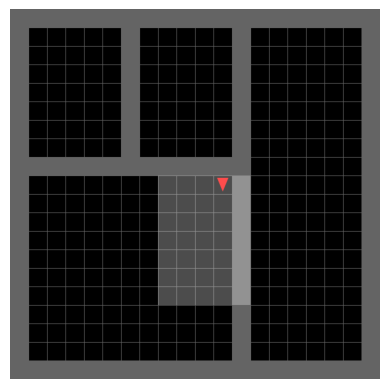

In [13]:
import matplotlib.pyplot as plt

frame = env.render()

plt.imshow(frame)
plt.axis('off') # Versteckt die Achsen (x/y Koordinaten)
plt.show()